In [ ]:
import shap
import joblib
import pandas as pd

In [4]:
# Load data
X = pd.read_csv("data/pca_8_components.csv")
y = pd.read_csv("data/labels.csv").squeeze()

# Load model
gmm = joblib.load("models/gmm_model.pkl")

# Prediction function (probabilities)
def gmm_predict_proba(X):
    return gmm.predict_proba(X)


c:\Users\kdarzadon\Documents\PGD for AI or ML\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/500 [00:00<?, ?it/s]

c:\Users\kdarzadon\Documents\PGD for AI or ML\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
c:\Users\kdarzadon\Documents\PGD for AI or ML\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
c:\Users\kdarzadon\Documents\PGD for AI or ML\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
c:\Users\kdarzadon\Documents\PGD for AI or ML\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
c:\Users\kdarzadon\Documents\PGD for AI or ML\myenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

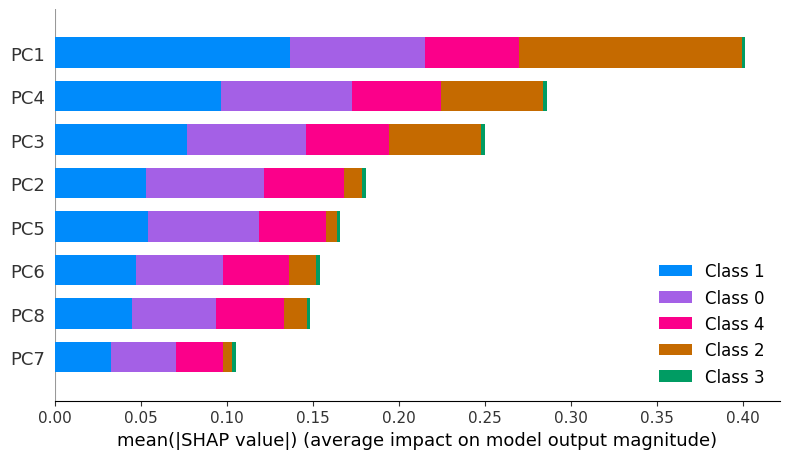

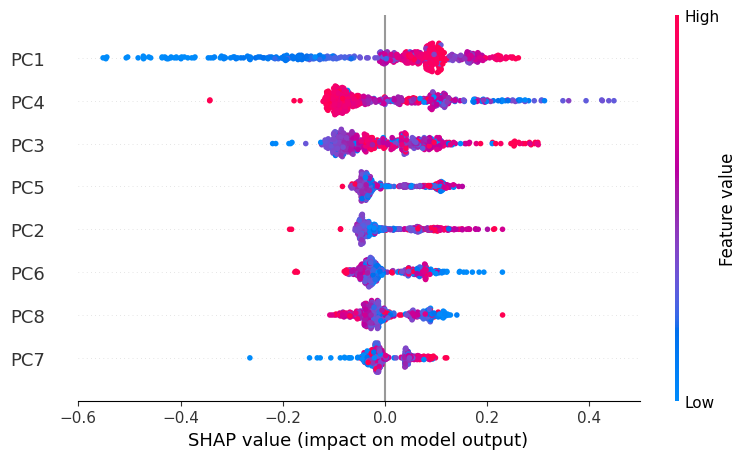

In [5]:
# Select a sample that includes all fault types
X_audit = X.sample(500, random_state=42) 

# Use a larger background set if possible (e.g., 200-500)
explainer = shap.KernelExplainer(gmm_predict_proba, shap.sample(X, 200))
shap_values = explainer.shap_values(X_audit)

# 1. Feature Importance (Bar Plot) - Shows which PC the model trusts most
shap.summary_plot(shap_values, X_audit, plot_type="bar")

X_audit_np = X_audit.values

# If shap_values is a list (common case)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_audit_np, feature_names=X.columns)

# If it's a 3D array
else:
    shap.summary_plot(shap_values[:, :, 1], X_audit_np, feature_names=X.columns)